# 📊Data Cleaning, Exploratory Data Analysis (EDA), & Feature Engineering

## 📝 Project Overview
This notebook covers the initial phase of our end-to-end Heart Disease classification pipeline. The primary objective is to ingest the raw medical dataset, audit its quality, uncover foundational statistical patterns, and transform the raw attributes into model-ready features.

---

## 🛠️ Key Process Phases

### 1. 🧼 Data Auditing & Cleaning
* **Missing Value Analysis:** Structural verification for null attributes and implementation of robust imputation strategies where necessary.
* **Data Type Alignment:** Ensuring categorical, integer, and floating-point data fields are mapped onto their optimal memory signatures.
* **Anomaly & Outlier Detection:** Inspecting distribution tails to isolate and handle statistical noise.

### 2. 🔍 Exploratory Data Analysis (EDA)
* **Target Distribution Mapping:** Analyzing the balance of our target labels (**Label 0: Condition Present** / **Label 1: Condition Absent**).
* **Univariate Features Analysis:** Plotting distributions for critical health markers (such as age, blood pressure, cholesterol) using histograms and density plots.
* **Bivariate & Multivariate Relationships:** Utilizing correlation matrices, box plots, and pair plots to isolate the strong statistical indicators correlated directly with the target diagnosis.

### 3. ⚙️ Feature Engineering & Transformation
* **Categorical Encoding:** Converting nominal/ordinal features into numerical vectors using One-Hot and Label Encoding.
* **Feature Scaling:** Adjusting the variance and scale of continuous variables via standardization/normalization techniques to prepare them for downstream mathematical optimization.
* **Feature Creation:** Extracting interactions or binned risks to give our machine learning models a clearer predictive signal.

## 📦 Step 1: Environment Setup & Library Dependencies

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 📁 Step 2: Data Ingestion & Features Dictionary

We load the raw dataset into a pandas DataFrame and inspect its structure. Below is the data dictionary mapping out what each medical feature represents:

### 📋 Feature Attributes Breakdown

| Column Name | Data Type | Description / Accepted Values |
| :--- | :--- | :--- |
| **Patient_Age** | Continuous | The age of the patient in years. |
| **Gender** | Categorical | Biological sex: `1` = Male, `0` = Female. |
| **Chest_Pain_Type** | Categorical | Pain category (`0` to `3`): Typical angina, atypical angina, non-anginal, asymptomatic. |
| **Resting_Blood_Pressure** | Continuous | Resting blood pressure in mm Hg upon hospital admission. |
| **Serum_Cholestoral** | Continuous | Patient's serum cholesterol measurement in mg/dl. |
| **Fasting_Blood_Sugar** | Binary | Fasting blood sugar > 120 mg/dl: `1` = True, `0` = False. |
| **Resting_Electrocardiographic** | Categorical | Resting ECG results (`0` to `2`): Normal, ST-T wave abnormality, left ventricular hypertrophy. |
| **Maximum_Heart_Rate** | Continuous | Highest heart rate achieved during an exercise stress test. |
| **Exercise_Induced_Angina** | Binary | Did exercise induce chest pain? `1` = Yes, `0` = No. |
| **ST_depression_induced_exercise** | Continuous | ECG ST segment depression value induced by exercise relative to rest. |
| **Slope_peak_exercise** | Categorical | Slope of peak exercise ST segment (`0` to `2`): Upsloping, flat, downsloping. |
| **Major_vessels_colored** | Discrete | Number of major blood vessels (`0`–`4`) visible under fluoroscopy X-ray. |
| **thal** | Categorical | Thalassemia blood disorder type: `1` = Fixed defect, `2` = Normal, `3` = Reversible defect. |
| **target** | Binary | **Classification Label:** `0` = Condition Present (Heart Disease), `1` = Condition Absent (Healthy). |

In [24]:
data_path = "../Data/Raw/H.csv"
df = pd.read_csv(data_path)
df.head()

,Patient_Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholestoral,Fasting_Blood_Sugar,Resting_Electrocardiographic,Maximum_Heart_Rate,Exercise_Induced_Angina,ST_depression_induced_exercise,Slope_peak_exercise,Major_vessels_colored,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 🧼 Step 3: Data Cleaning & Preprocessing

### 🔍 Phase 3.1: Initial Data Quality Assessment & Structural Audit

In [25]:
#Structural Integrity Audit
print("DataSet Shape")
rows, cols = df.shape
print(f"Total Patients Records = {rows}")
print(f"Total Clinical Features = {cols}")

print("="*40)
print("Columns Data Types and Non_Null counts")
print("="*40)
df.info()

print("="*40)
print("Whitspaces and Anomoly Audit")
print("="*40)
white_spaces_issues = 0
for col in df.columns:
  if col.strip() !=col:
    print(f"Warning: Column {col} contain hidden leading/tainling whitespace")
    white_spaces_issues += 1

if white_spaces_issues == 0 :
  print("No WhiteSpaces")
else:
  print(f"Total issues found = {white_spaces_issues}")



DataSet Shape
Total Patients Records = 303
Total Clinical Features = 14
Columns Data Types and Non_Null counts
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient_Age                     303 non-null    int64  
 1   Gender                          303 non-null    int64  
 2   Chest_Pain_Type                 303 non-null    int64  
 3   Resting_Blood_Pressure          303 non-null    int64  
 4   Serum_Cholestoral               303 non-null    int64  
 5   Fasting_Blood_Sugar             303 non-null    int64  
 6   Resting_Electrocardiographic    303 non-null    int64  
 7   Maximum_Heart_Rate              303 non-null    int64  
 8   Exercise_Induced_Angina         303 non-null    int64  
 9   ST_depression_induced_exercise  303 non-null    float64
 10  Slope_peak_exercise             303 non-null    int64  
 1

### 🧼 Phase 3.2: Duplicate Record Audit & Removal

In [12]:
print("Check Duplication")
duplicated_count = df.duplicated().sum()
print("="*40)
print("Start Duplication Audit")
print("="*40)
print(f"Total duplicate rows detected: {duplicated_count}")
print("="*40)

if duplicated_count > 0:
  print("Displaying Duplicated Rows")
  pd.set_option("display.max_columns",None) # forcing pandas to show all columns
  display(df[df.duplicated(keep=False)])


if duplicated_count > 0 :
  df = df.drop_duplicates()
else:
  print("No Duplicates Found")
print(f"New Dataset Shape : {df.shape[0]} rows, {df.shape[1]} columns ")

Check Duplication
Start Duplication Audit
Total duplicate rows detected: 1
Displaying Duplicated Rows


,Patient_Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholestoral,Fasting_Blood_Sugar,Resting_Electrocardiographic,Maximum_Heart_Rate,Exercise_Induced_Angina,ST_depression_induced_exercise,Slope_peak_exercise,Major_vessels_colored,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


New Dataset Shape : 302 rows, 14 columns 


### 🔍 Phase 3.3: Comprehensive Missing Value & Hidden Placeholder Audit

In [26]:
print("Check Missing Values")
print("="*40)
standard_missing = df.isnull().sum()
#Check for common hidden placeholders in object/string columns
question_marks = (df == '?').sum()
empty_strings = (df == ' ').sum()
#Check for invalid placeholder flags (like -1) in strictly positive columns
# (Age, Blood Pressure, and Cholesterol cannot logically be negative or zero)
negative_ones = (df[['Patient_Age', 'Resting_Blood_Pressure', 'Serum_Cholestoral']] == -1).sum()

missing_summary = pd.DataFrame({
    'Standard Nan':standard_missing,
    "Hidden":question_marks,
    "Hidden Spaces":empty_strings
})

#Add another column
missing_summary['-1 Flags'] = 0
for col in negative_ones.index:
    missing_summary.loc[col, '-1 Flags'] = negative_ones[col]
print("Summary of Missing Values and Placeholders per Column:")
print(missing_summary)
print("-" * 40)

Check Missing Values
Summary of Missing Values and Placeholders per Column:
                                Standard Nan  Hidden  Hidden Spaces  -1 Flags
Patient_Age                                0       0              0         0
Gender                                     0       0              0         0
Chest_Pain_Type                            0       0              0         0
Resting_Blood_Pressure                     0       0              0         0
Serum_Cholestoral                          0       0              0         0
Fasting_Blood_Sugar                        0       0              0         0
Resting_Electrocardiographic               0       0              0         0
Maximum_Heart_Rate                         0       0              0         0
Exercise_Induced_Angina                    0       0              0         0
ST_depression_induced_exercise             0       0              0         0
Slope_peak_exercise                        0       0              

### 🧼 Phase 3.4: Outlier Analysis via Robust Statistical Boundaries

#### 📊 Method Selection: The Interquartile Range ($IQR$) Strategy
Instead of using standard deviation Z-scores or other distance-based outlier methods, we isolate anomalies in this dataset using the **Interquartile Range ($IQR$) method**:
* **Robust to Skewed Distributions (Non-Parametric):** Clinical vitals (like serum cholesterol or resting blood pressure) are rarely perfectly symmetric and are frequently skewed by high-risk medical exceptions. Because the $IQR$ method relies strictly on percentiles ($Q1$ and $Q3$) rather than the sample mean and variance, it remains completely unwarped by extreme values.
* **Protects Against the "Masking Effect":** The masking effect occurs when severe outliers falsely inflate the standard deviation, making other genuine anomalies appear "normal" by comparison. $IQR$ fixes this by calculating boundaries based strictly on the stable, middle **50%** of the patient population.

#### 🧠 Architectural Choice: Why we used a `set()` instead of a `list()`
Inside our inspection loop, the variable `outlier_indices` is initialized as a Python `set()` and updated via `.update()`. 

If a single patient exhibits **both** critically high resting blood pressure *and* extreme serum cholesterol, their specific row index will be flagged twice during the loop iterations. 
* If we used a **list**, that duplicate index would be appended multiple times, artificially inflating our final count of anomalous profiles.
* By utilizing a **set**, Python enforces absolute uniqueness. Duplicate indices are instantly collapsed into a single instance, guaranteeing that `total_outlier_rows` reflects the true number of **unique physical patients** affected.

#### 🩺 Clinical Domain Realities: Keeping vs. Dropping Anomaly Profiles
While these rows are flagged as *statistical* anomalies by our mathematical thresholds, **a deep dive into the medical reality of these numbers proves that they are genuine, high-risk clinical profiles, not errors.** Extremely high cholesterol readings (e.g., >350 mg/dl) or severe ST segment depressions are legitimate physiological signs of advanced cardiovascular distress. Removing these records would strip the machine learning model of its most vital predictive indicators for catching severe heart disease. Consequently, these records are purposefully retained in our pipeline.

In [27]:
print("Check Outlier")
# Define the continuous numerical features to inspect
continuous_features = ['Resting_Blood_Pressure', 'Serum_Cholestoral', 'Maximum_Heart_Rate', 'ST_depression_induced_exercise']
outlier_indices = set()

for col in continuous_features :
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  column_outliers = df[(df[col] < lower_bound) | (df[col]> upper_bound)]
  num_outliers = len(column_outliers)
  print(f"   Middle 50% Range (IQR): {Q1} to {Q3}")
  print(f"   Statistical Normal Boundaries: {lower_bound:.2f} to {upper_bound:.2f}")
  print(f"   Outliers Detected: {num_outliers} row(s)")
  if num_outliers > 0:
        print(f"   Outlier values present: {column_outliers[col].values.tolist()}")
        outlier_indices.update(column_outliers.index)
  print("=" * 40)

total_outlier_rows = len(outlier_indices)
print(f"Total unique patient records containing at least one statistical outlier: {total_outlier_rows}")
print("=" * 40)


Check Outlier
   Middle 50% Range (IQR): 120.0 to 140.0
   Statistical Normal Boundaries: 90.00 to 170.00
   Outliers Detected: 9 row(s)
   Outlier values present: [172, 178, 180, 180, 200, 174, 192, 178, 180]
   Middle 50% Range (IQR): 211.0 to 274.5
   Statistical Normal Boundaries: 115.75 to 369.75
   Outliers Detected: 5 row(s)
   Outlier values present: [417, 564, 394, 407, 409]
   Middle 50% Range (IQR): 133.5 to 166.0
   Statistical Normal Boundaries: 84.75 to 214.75
   Outliers Detected: 1 row(s)
   Outlier values present: [71]
   Middle 50% Range (IQR): 0.0 to 1.6
   Statistical Normal Boundaries: -2.40 to 4.00
   Outliers Detected: 5 row(s)
   Outlier values present: [4.2, 6.2, 5.6, 4.2, 4.4]
Total unique patient records containing at least one statistical outlier: 19


## 🔍 Step 4: Exploratory Data Analysis (EDA)

### 📊 Phase 4.1: Target Class Balance Analysis

This phase evaluates the distribution of the dependent variable (`target`) to assess data balance. Analyzing class representation at this stage is essential, as it directly dictates our downstream model training choices and validation strategies:

* **No Imbalance Handling Needed:** You do not need to use complex sampling algorithms like SMOTE (Synthetic Minority Over-sampling Technique), random under-sampling, or class-weight adjustments during training. The dataset exhibits a healthy distribution across both outcomes.
* **Standard Evaluation Metrics Work Perfectly:** You will be able to trust standard evaluation metrics like Accuracy, Precision, Recall, and F1-Score completely when evaluating your models later. In heavily skewed datasets, metrics like accuracy become deceptive benchmarks; here, a balanced target distribution ensures standard performance metrics remain statistically reliable and interpretable.
* **Seamless Baseline Validation:** Because the representation is stable across categories, we will keep going with regular metrics without needing to implement custom cost-sensitive loss functions or complex stratified evaluation architectures.

In [28]:
print("Satarting EDA")
print("="*40)
print("Target Calss Balanace Analysis")
target_counts = df['target'].value_counts()
target_percentage = df['target'].value_counts(normalize=True)*100
print("Target Distribution")
for status, count in target_counts.items():
  label = "Heart Disease (1) =" if status ==1 else "Healthy (0) = "
  pct = target_percentage[status]
  print(f"{label} {count} ({pct:.2f}%)")


Satarting EDA
Target Calss Balanace Analysis
Target Distribution
Heart Disease (1) = 165 (54.46%)
Healthy (0) =  138 (45.54%)


### 📊 Phase 4.2: Distribution Profiling via Univariate Analysis

This phase focuses on visual profiling of the continuous clinical features to inspect their central tendency, spread, and underlying statistical shape. 

#### ⚠️ Critical Modeling Insight: The Necessity of Feature Scaling
A key takeaway from visualizing these distributions is the drastic variation in absolute scale across features. For example, `Serum_Cholestoral` spans values up to **564 mg/dl**, whereas `Patient_Age` strictly stops at **77 years**. 

Because your features don't all share the same ranges, feeding these raw distributions directly into distance-based or gradient-descent machine learning algorithms (like **Logistic Regression, KNN, or SVM**) will cause the model to ignore Age and fixate entirely on Cholesterol. The algorithm will misinterpret the larger numeric scales as inherently more important. To neutralize this mathematical bias, we must implement a **Feature Scaling (Standardization)** step downstream before training.

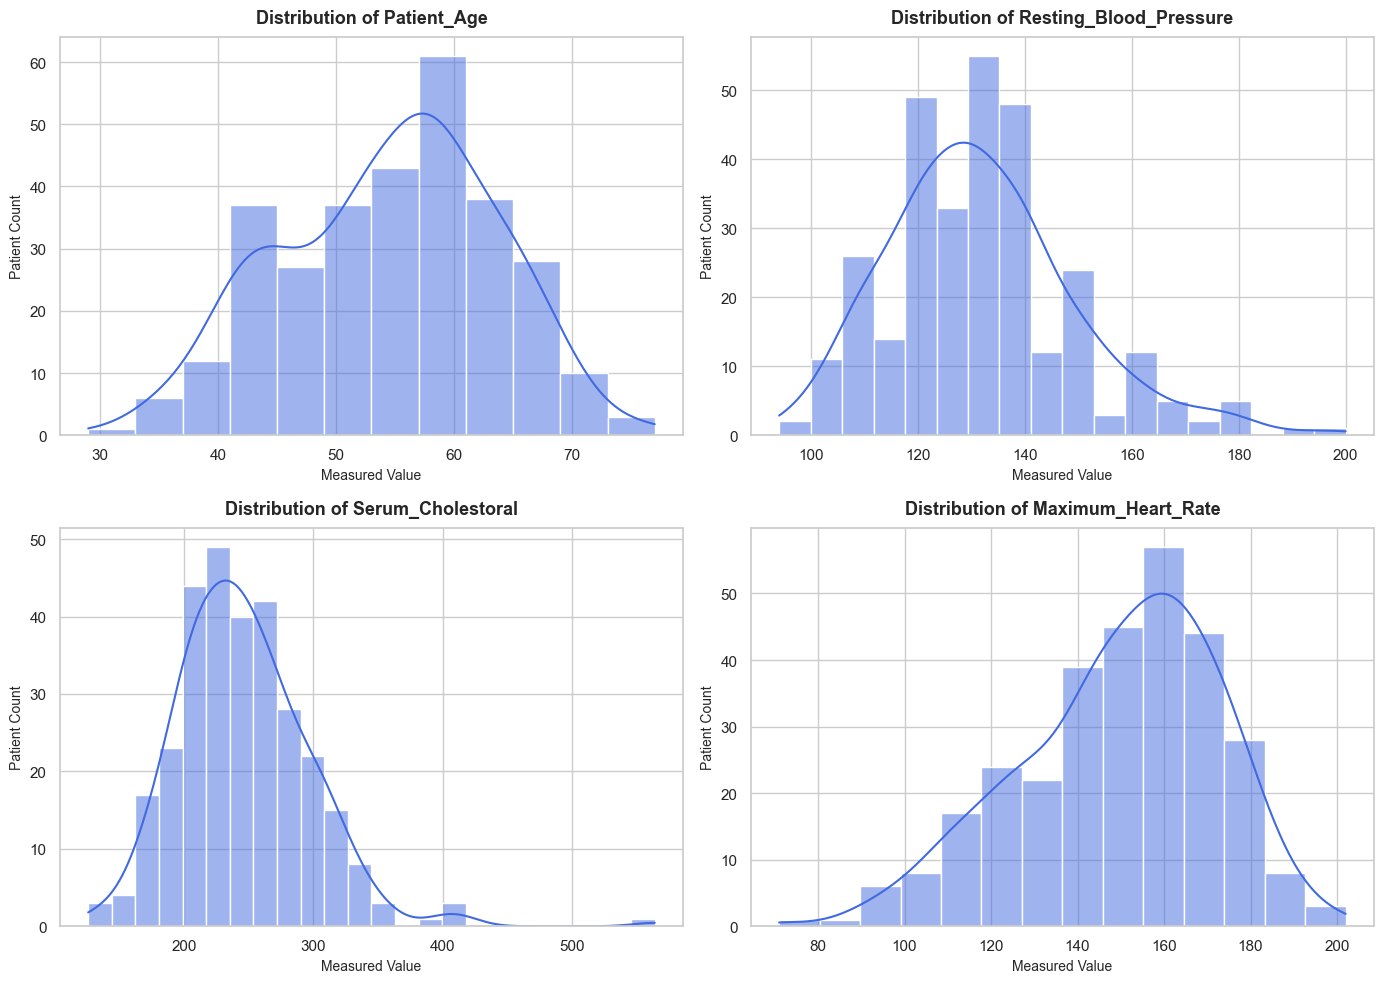

In [29]:
#distribution profiling "Univariant Analysis"

#set clean visual theme
sns.set_theme(style="whitegrid")
#define continous features
continuous_features = ['Patient_Age','Resting_Blood_Pressure','Serum_Cholestoral','Maximum_Heart_Rate']
fig,axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()
for i,col in enumerate(continuous_features):
  sns.histplot(data= df,x=col,kde=True,ax=axes[i],color='royalblue',edgecolor='white')
  axes[i].set_title(f"Distribution of {col}",fontsize=13,fontweight='bold',pad=10)
  axes[i].set_xlabel("Measured Value",fontsize=10)
  axes[i].set_ylabel("Patient Count",fontsize=10)

plt.tight_layout()
plt.show()

### 📊 Phase 4.3: Clinical Risk Correlation Matrix (Bivariate Analysis)

This phase explores the linear relationships between our continuous clinical risk factors and the final target diagnosis using a Pearson correlation heatmap.

#### 🎯 Feature Selection Strategy: Why Only These Columns?
You will notice that we did not include the entire dataset in this matrix. The reason we only chose those specific features comes down to a fundamental rule of statistics: **Pearson's Correlation Coefficient ($r$) only works on truly continuous numerical data.** * **The Problem with Categorical Features:** Applying Pearson correlation to nominal or binary categorical variables (such as `Gender`, `Chest_Pain_Type`, or `Slope_peak_exercise`) yields mathematically invalid or highly deceptive coefficients. This is because the arbitrary numeric labels assigned to categories do not represent an actual quantitative continuum.
* **Our Approach:** To maintain absolute statistical integrity, we isolated strictly continuous physiological metrics (`Patient_Age`, `Resting_Blood_Pressure`, `Serum_Cholestoral`, `Maximum_Heart_Rate`, and `ST_depression_induced_exercise`) alongside our binary `target` label to evaluate their direct linear correlation trends.

Calculate Clinical Risk Correlation Matrix


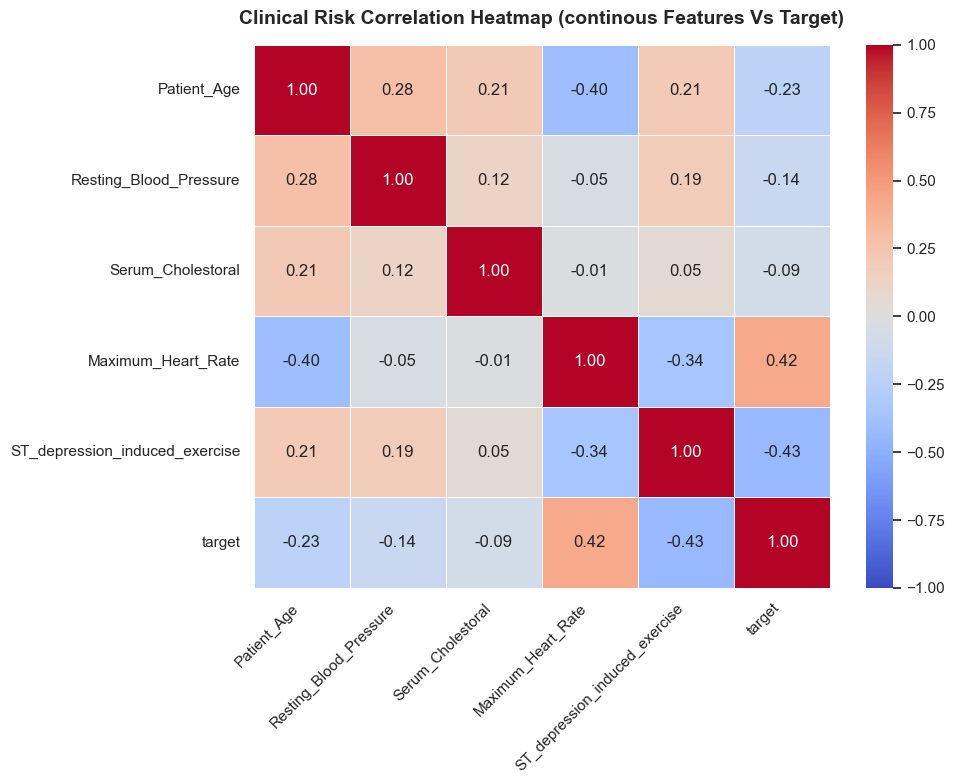

In [30]:
#Clinical Risk Correlation (Bivariate Analysis)
print("Calculate Clinical Risk Correlation Matrix")
correlation_features = ['Patient_Age', 'Resting_Blood_Pressure', 'Serum_Cholestoral',
                        'Maximum_Heart_Rate', 'ST_depression_induced_exercise', 'target']
corr_matrix = df[correlation_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Clinical Risk Correlation Heatmap (continous Features Vs Target)",fontsize=14,fontweight='bold',pad=15 )
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 📊 Phase 4.4: Categorical Stratification Analysis

This phase shifts our exploration to the categorical attributes that could not be evaluated using the Pearson correlation matrix.

#### 📈 Method Selection: Pivot to Category Stratification
The Pearson correlation matrix has one strict rule: it requires a continuous, mathematical scale where numbers mean "more" or "less" of a physical quantity. Since we cannot use a linear correlation matrix on categories, we switch to Category Stratification. 

This means we split (stratify) our patient data into groups based on their specific categories (such as chest pain types or thalassemia variants) and then calculate the relative percentage of the target diagnosis within each isolated sub-group. 

#### 🚀 Modeling Implications & Feature Signals
No data modifications or fixes are needed. Sometimes when people see such a stark contrast in sub-category distributions, they worry that the data is "too perfect" or that they need to balance the sub-categories. You don't! 

This clean separation is exactly what you are looking for in Exploratory Data Analysis. It confirms that you have incredibly strong signals in your categorical features, meaning tree-based algorithms like **Random Forest or Gradient Boosting** are going to perform phenomenally well on this data by exploiting these clean statistical splits.

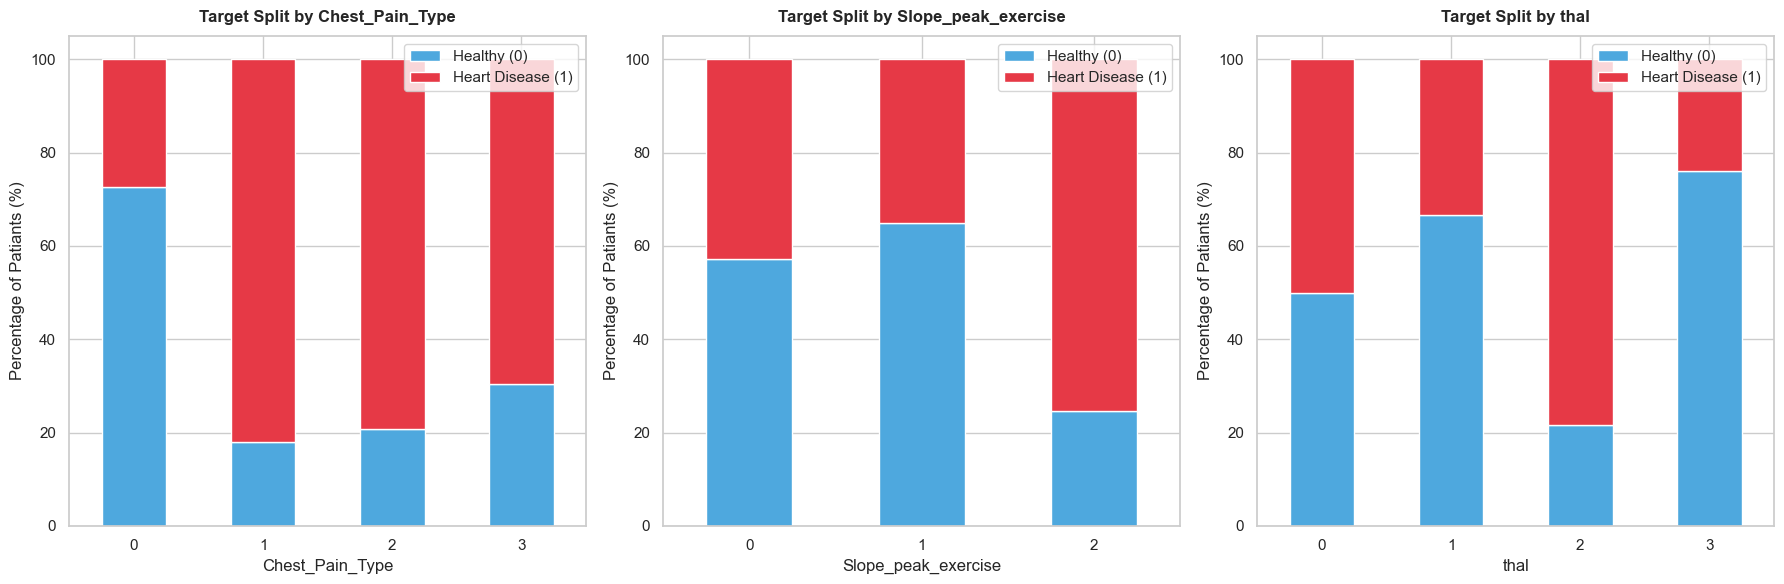

In [31]:
#GENERATING CATEGORICAL STRATIFICATION CHARTS
categorical_features = ['Chest_Pain_Type',"Slope_peak_exercise",'thal']
fig,axes = plt.subplots(1,3,figsize=(18,6))
axes = axes.flatten()

#Loop through Each Categorical feature
for i,col in enumerate(categorical_features):
  crosstab_pct = pd.crosstab(df[col],df['target'], normalize='index')*100
  crosstab_pct.plot(kind='bar', stacked=True, color=['#4ea8de', '#e63946'], ax=axes[i], edgecolor='white')
  axes[i].set_title(f"Target Split by {col}",fontsize=12,fontweight='bold',pad=10)
  axes[i].set_xlabel=("Category Code")
  axes[i].set_ylabel('Percentage of Patiants (%)')
  axes[i].legend(['Healthy (0)','Heart Disease (1)'],loc='upper right')
  axes[i].tick_params(axis='x',rotation=0)

plt.tight_layout()
plt.show()

## 🛠️ Step 5: Feature Engineering & Encoding

### 🏷️ Phase 5.1: Explicit Categorical Remapping

Before converting categorical variables into a machine-learning-ready format, we must transform the arbitrary integer codes into human-readable string descriptions.

#### 🧠 Architectural Strategy: Why Remap Integers to Text?
Right now, your categorical columns like `Chest_Pain_Type` and `thal` contain numeric integers ($0, 1, 2, 3$). If you jump straight to automated one-hot encoding methods (like using `pd.get_dummies(df)`), pandas has no way of knowing that those columns are actually text-based categories. It will treat them as numbers, skip them entirely, or output messy column headers like `Chest_Pain_Type_0`, `Chest_Pain_Type_1`, etc.

To circumvent this and build a production-grade feature pipeline, we map these columns explicitly:
* **Prevents Typing Errors:** Converting the integers to strings forces pandas to recognize the features as nominal `object` datatypes, ensuring seamless handling by automated encoding functions.
* **Self-Documenting Features:** Upstream transformations will automatically extract the human-readable text to name new features. This keeps feature headers clean, meaningful, and perfectly aligned with our clinical domain knowledge.

In [32]:
#TARTING EXPLICIT CATEGORICAL REMAPPING
chest_pain_map = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
}

slope_map = {
    0: 'Upsloping',
    1: 'Flat',
    2: 'Downsloping'
}

thal_map = {
    0: 'Unknown/Null',
    1: 'Normal',
    2: 'Fixed Defect',
    3: 'Reversible Defect'
}
df_mapped = df.copy()
df_mapped['Chest_Pain_Type'] = df_mapped['Chest_Pain_Type'].map(chest_pain_map)
df_mapped['Slope_peak_exercise'] = df_mapped['Slope_peak_exercise'].map(slope_map)
df_mapped['thal'] = df_mapped['thal'].map(thal_map)

print("Success: Categorical variables mapped to descriptive text strings")
print("Quick Sample of Remapped Data Fields")
print(df_mapped[['Chest_Pain_Type','Slope_peak_exercise','thal']].head())


Success: Categorical variables mapped to descriptive text strings
Quick Sample of Remapped Data Fields
    Chest_Pain_Type Slope_peak_exercise          thal
0      Asymptomatic           Upsloping        Normal
1  Non-anginal Pain           Upsloping  Fixed Defect
2   Atypical Angina         Downsloping  Fixed Defect
3   Atypical Angina         Downsloping  Fixed Defect
4    Typical Angina         Downsloping  Fixed Defect


### 🧬 Phase 5.2: One-Hot Encoding via Dummy Variable Explosion

This phase completes the preparation of our nominal categorical attributes by transforming them into distinct binary numeric vectors suitable for machine learning algorithms.

#### 📝 Note on One-Hot Encoding & The Baseline Reference Group

When exploding our categorical text features into binary indicators, we explicitly set `drop_first=True`. This drops one category from each feature to serve as our **Baseline Reference Group** and prevents **Multicollinearity** (the Dummy Variable Trap), which stabilizes our upcoming machine learning models.

#### How the Model Recovers the Dropped Data:
No information or rows are lost. The model uses pure logical and mathematical elimination to evaluate the dropped categories:

1. **Logical Elimination (Tree Models):** If a patient evaluates to `0` for all remaining dummy columns of a feature, the model logically concludes they belong to the dropped baseline category.
2. **Mathematical Absorption (Linear Models):** When all dummy columns for a feature collapse to `0`, their respective coefficients drop out of the risk equation. The model's **Intercept ($b$)** automatically absorbs and represents the exact weight and clinical risk of that dropped reference category.

#### Our Engineered Reference Baseline Map:
* **Dropped `Chest_Pain_Type_Typical Angina`** $\rightarrow$ Remaining columns calculate risk *relative* to a patient having Typical Angina.
* **Dropped `Slope_peak_exercise_Downsloping`** $\rightarrow$ Remaining columns calculate risk *relative* to a patient having a Downsloping ST segment.
* **Dropped `thal_Unknown/Null`** $\rightarrow$ Remaining columns calculate risk *relative* to this baseline state.

In [33]:
#EXECUTING ONE-HOT DUMMY EXPLOSION
columns_to_encode = ['Chest_Pain_Type', 'Slope_peak_exercise', 'thal']
df_processed = pd.get_dummies(
    df_mapped,
    columns=columns_to_encode,
    drop_first = True,
    dtype=int
)
print("Catogrical text strings explode into distinct binary indicator")
print(f'orgiginal dataframe shape : {df_mapped.shape}')
print(f"Post-Explosion DataFrame shape : {df_processed.shape}")
print("New Feature Inventory (First 15 columns shown):")
for col in list(df_processed.columns)[:15]:
    print(f" - {col}")


Catogrical text strings explode into distinct binary indicator
orgiginal dataframe shape : (303, 14)
Post-Explosion DataFrame shape : (303, 19)
New Feature Inventory (First 15 columns shown):
 - Patient_Age
 - Gender
 - Resting_Blood_Pressure
 - Serum_Cholestoral
 - Fasting_Blood_Sugar
 - Resting_Electrocardiographic
 - Maximum_Heart_Rate
 - Exercise_Induced_Angina
 - ST_depression_induced_exercise
 - Major_vessels_colored
 - target
 - Chest_Pain_Type_Atypical Angina
 - Chest_Pain_Type_Non-anginal Pain
 - Chest_Pain_Type_Typical Angina
 - Slope_peak_exercise_Flat


### 🧬 Phase 5.3: Data Splitting & Variance Scaling (Standardization)

This final preprocessing phase prepares our feature matrices for model ingestion by enforcing structural separation and numerical uniformity.

#### ⛔ The Golden Rule: Prevent Data Leakage via Proper Partition Sequence
Before we run the code to scale your data, we must address an absolute golden rule of machine learning: **We must split our dataset into Training (80%) and Testing (20%) data before we calculate any scaling factors.**

If you calculate the average mean and standard deviation using the entire dataset, information from your test set will leak into your training process. This is a severe pipeline flaw called **Data Leakage**. It gives your model an artificial, cheating glimpse at data it shouldn't know about yet, leading to overly optimistic training metrics but terrible performance when deployed on real, unseen future patients. By splitting first, we ensure that scaling parameters are derived *strictly* from the training subset.

#### 🧮 Variance Scaling (Standardization)
As discovered during our univariate distribution profiling, features with massive absolute ranges (like `Serum_Cholestoral` reaching up to 564) would inherently overwhelm features with smaller numeric bounds (like `Patient_Age`). 

Variance Scaling (Standardization) fixes this by converting every continuous measurement into a universal mathematical currency: **Z-scores**. This scales the features so they have a mean of $0$ and a standard deviation of $1$, neutralizing scale bias while completely preserving the shape of the original underlying distribution.

#### 📂 Production-Grade Engineering: Saving the Scaler Artifact
When building backend API endpoints for inference pipelines, you cannot just scale your training dataset in a vacuum. Incoming real-time patient payloads will arrive as raw numbers (e.g., a cholesterol value of 240). 

To process these incoming requests correctly, the exact same mathematical properties (the mean and variance learned from the training set) must be applied. For this reason, we explicitly persist the fitted `StandardScaler` instance into our production `models/` directory as a serialized joblib artifact (`StandardScaler_model.joblib`), making it ready for a fastAPI or Streamlit backend.

In [42]:
#Excuting Data Spliting & Variance Scaling
x = df_processed.drop(columns=['target'])
y = df_processed['target']

#excute train test split with 80% percent training and 20% tesiting
#stratify , to save same distribution balance between 0,1 on
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.20,stratify =y , random_state=42
)
scaler = StandardScaler()
continuous_features = ['Patient_Age', 'Resting_Blood_Pressure', 'Serum_Cholestoral',
                       'Maximum_Heart_Rate', 'ST_depression_induced_exercise']
x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[continuous_features] = scaler.fit_transform(x_train[continuous_features])
x_test_scaled[continuous_features] = scaler.transform(x_test[continuous_features])

# i creatd this part when i was building the backend , so i had to type it that way 
PROJECT_ROOT = Path.cwd().parent
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)
joblib.dump(scaler, models_dir / "StandardScaler_model.joblib")

['c:\\Users\\DELL\\Downloads\\Diesease_prediction_project\\models\\StandardScaler_model.joblib']

### 💾 Phase 5.4: Pipeline Serialization & Clean Feature Export

This final phase concludes our data preparation notebook by persisting our model-ready features and target matrices to storage, establishing a clean boundary between preprocessing and model training.

#### 🗄️ Architectural Strategy: Decoupling Components
Instead of keeping the entire machine learning lifecycle inside a single massive, unmanageable notebook, standard production engineering requires decoupling your phases:
1. **Data Ingestion, Cleaning, and Preprocessing** (This notebook)
2. **Model Training, Evaluation, and Hyperparameter Optimization** (Downstream scripts)

By explicitly exporting our partitioned data (`x_train_scaled`, `x_test_scaled`, `y_train`, and `y_test`) into clean, independent CSV files under a dedicated processed data directory (`../Data/Final/`), we ensure that our modeling phase can load uniform data structures instantly. This avoids running the entire data cleaning and standardization routine from scratch each time a new model iteration is tested.

In [ ]:
#Save and export data
export_package = {
    'x_train_scaled.csv': x_train_scaled,
    'x_test_scaled.csv': x_test_scaled,
    'y_train.csv': y_train,
    'y_test.csv': y_test
}

for filename, dataset in export_package.items():
    path = os.path.join("../Data/Final/", filename)
    dataset.to_csv(path, index=False)
    print(f"Successfully exported: {path} ({dataset.shape[0]} rows)")

Successfully exported: ../Data/Final/x_train_scaled.csv (241 rows)
Successfully exported: ../Data/Final/x_test_scaled.csv (61 rows)
Successfully exported: ../Data/Final/y_train.csv (241 rows)
Successfully exported: ../Data/Final/y_test.csv (61 rows)
